In [2]:
import pandas as pd

In [3]:
cast = pd.read_csv('E:/Datasets/cast.csv')
cast.head()

,title,year,name,type,character,n
0,Closet Monster,2015.0,Buffy #1,actor,Buffy 4,NaN
1,Suuri illusioni,1985.0,Homo $,actor,Guests,22.0
2,Battle of the Sexes,2017.0,$hutter,actor,Bobby Riggs Fan,10.0
3,Secret in Their Eyes,2015.0,$hutter,actor,2002 Dodger Fan,NaN
4,Steve Jobs,2015.0,$hutter,actor,1988 Opera House Patron,NaN


### How many movies are listed in the cast dataframe?

In [7]:
print("Theere are", cast['title'].nunique(), "movies in the cast dataframe")

Theere are 166670 movies in the cast dataframe


### What are the earliest two films listed in the cast dataframe?

In [22]:
k = cast[['title','year']].sort_values('year').drop_duplicates().head(2)['title'].unique()
print(f"The earliest two films are as - {k[0]} and {k[1]} ")

The earliest two films are as - Miss Jerry and Soldiers of the Cross 


In [28]:
df = cast.dropna()
df

,title,year,name,type,character,n
1,Suuri illusioni,1985.0,Homo $,actor,Guests,22.0
2,Battle of the Sexes,2017.0,$hutter,actor,Bobby Riggs Fan,10.0
8,"Lapis, Ballpen at Diploma, a True to Life Journey",2014.0,Jori ' Danilo' Jurado Jr.,actor,Jaime (young),9.0
10,When the Man Went South,2014.0,Taipaleti 'Atu'ake,actor,Two Palms - Ua'i Paame,8.0
11,Little Angel (Angelita),2015.0,Michael 'babeepower' Viera,actor,Chico,9.0
...,...,...,...,...,...,...
2159943,The Jury of Fate,1917.0,Albert Tavernier,actor,Henri Labordie,4.0
2159944,The Man from Beyond,1922.0,Albert Tavernier,actor,Dr. Crawford Strange,3.0
2159945,The Man Who Made Good (II),1917.0,Albert Tavernier,actor,Pop Clark,5.0
2159946,The Painted Madonna,1917.0,Albert Tavernier,actor,Rev. Charles Lamb,5.0


In [35]:
df.set_index('year').sort_index().head(2)['title'].unique()

array(['The Joe Gans-Battling Nelson Fight',
       'The Story of the Kelly Gang'], dtype=object)

### How many movies have the title "Hamlet"?

In [48]:
cast.shape

(2159949, 6)

In [49]:
%time
(cast['title']=='Hamlet').sum()

CPU times: total: 0 ns
Wall time: 0 ns


218

In [50]:
%time
j = cast.set_index('title')  ###### Much faster
len(j.loc['Hamlet'])

CPU times: total: 0 ns
Wall time: 0 ns


218

### How many movies are titled "North by Northwest"?

In [58]:
j = cast.set_index('title')  ###### Much faster
print(f"There are total  - {len(j.loc['North by Northwest'])} movies title by North by Northwest")

There are total  - 81 movies title by North by Northwest


### When was the first movie titled "Hamlet" made?

In [61]:
cast[cast['title']=='Hamlet']['year'].min()

1910.0

In [65]:
cast[cast['title']=='Hamlet'].sort_values('year').head(1)

,title,year,name,type,character,n
1545289,Hamlet,1910.0,Jean Mounet-Sully,actor,Hamlet,NaN


### List all of the "Treasure Island" movies from earliest to most recent.

In [66]:
cast[cast['title']=='Treasure Island'].sort_values('year')

,title,year,name,type,character,n
1291387,Treasure Island,1918.0,Elmo Lincoln,actor,Prologue Player,NaN
830114,Treasure Island,1918.0,Charles Gorman,actor,Prologue Player,NaN
840745,Treasure Island,1918.0,Joe Grant,actor,Undetermined child role,NaN
909157,Treasure Island,1918.0,Edwin Harley,actor,Prologue Player,NaN
1946119,Treasure Island,1918.0,Lewis Sargent,actor,Ben Gunn,5.0
...,...,...,...,...,...,...
1959741,Treasure Island,1999.0,Richard Schave,actor,Man,21.0
872384,Treasure Island,1999.0,Paul Gutrecht,actor,Some Guy,20.0
210668,Treasure Island,1999.0,Jonah Blechman,actor,The Body,3.0
1869989,Treasure Island,1999.0,Scot Thomas Robinson,actor,Jimmy,11.0


### How many movies were made in the year 1950?

In [74]:
cast[cast['year']==1950]['title'].nunique()

884

### How many movies were made in the year 1960?

In [75]:
cast[cast['year']==1960]['title'].nunique()

1050

### How many movies were made from 1950 through 1959?

In [76]:
cast[(cast['year']>=1950)& (cast['year']<=1959)]['title'].nunique()

9827

### In what years has a movie titled "Batman" been released?

In [79]:
cast[cast['title']=='Batman']['year'].min()

1943.0

### How many roles were there in the movie "Inception"?

In [83]:
cast[cast['title']=='Inception']['character'].nunique()

42

### How many roles in the movie "Inception" are NOT ranked by an "n" value?

In [93]:
cast[cast['title']=='Inception']['n'].isnull().sum()

21

### But how many roles in the movie "Inception" did receive an "n" value?

In [91]:
cast[cast['title']=='Inception']['n'].notnull().sum()

31

### Display the cast of "North by Northwest" in their correct "n"-value order, ignoring roles that did not earn a numeric "n" value.

In [100]:
nw = cast[cast['title']=='North by Northwest'].sort_values('n')
nw[nw['n'].notnull()]

,title,year,name,type,character,n
840374,North by Northwest,1959.0,Cary Grant,actor,Roger O. Thornhill,1.0
1404704,North by Northwest,1959.0,James Mason,actor,Phillip Vandamm,3.0
343701,North by Northwest,1959.0,Leo G. Carroll,actor,The Professor,5.0
1634552,North by Northwest,1959.0,Philip Ober,actor,Lester Townsend,7.0
1229083,North by Northwest,1959.0,Martin Landau,actor,Leonard,8.0
1746383,North by Northwest,1959.0,Edward Platt,actor,Victor Larrabee,10.0
642085,North by Northwest,1959.0,Robert Ellenstein,actor,Licht,11.0
447893,North by Northwest,1959.0,Philip Coolidge,actor,Dr. Cross,13.0
1454363,North by Northwest,1959.0,Patrick McVey,actor,Sergeant Flamm,14.0
198496,North by Northwest,1959.0,Edward Binns,actor,Captain Junket,15.0


### Display the entire cast, in "n"-order, of the 1972 film "Sleuth".

In [110]:
t = cast.set_index(['title','year'])
t.loc['Sleuth'].loc[1972.0].sort_values('n')

,name,type,character,n
year,,,,
1972.0,Laurence Olivier,actor,Andrew Wyke,1.0
1972.0,Michael Caine,actor,Milo Tindle,2.0
1972.0,Alec Cawthorne,actor,Inspector Doppler,3.0
1972.0,John (II) Matthews,actor,Detective Sergeant Tarrant,4.0
1972.0,Teddy Martin,actor,Police Constable Higgs,6.0


### Now display the entire cast, in "n"-order, of the 2007 version of "Sleuth".

In [115]:
# t = cast.set_index(['title','year'])
t.loc['Sleuth'].loc[2007.0].sort_values('n')

,name,type,character,n
year,,,,
2007.0,Michael Caine,actor,Andrew,1.0
2007.0,Jude Law,actor,Milo,2.0
2007.0,Harold Pinter,actor,Man on T.V.,3.0
2007.0,Kenneth Branagh,actor,Other Man on T.V.,NaN
2007.0,Alec (II) Cawthorne,actor,Inspector Doppler,NaN


### How many roles were credited in the silent 1921 version of Hamlet?

In [119]:
cast[(cast['title']=='Hamlet')& (cast['year']==1921)]['character'].unique()

array(['Fortinbras,', 'K?nig Hamlet', 'Laertes', 'Polonius', 'Horatio'],
      dtype=object)

### How many roles were credited in Branagh’s 1996 Hamlet?

In [124]:
cast[(cast['title']=='Hamlet')& (cast['year']==1996)]['character'].nunique()

35

### How many "Hamlet" roles have been listed in all film credits through history?

In [128]:
cast[cast['character']=='Hamlet'].shape[0]

78

### How many people have played an "Ophelia"?

In [131]:
cast[cast['character']=='Ophelia']['name'].nunique()

7

### How many people have played a role called "The Dude"?

In [132]:
cast[cast['character']=='The Dude']['name'].nunique()

16

### How many people have played a role called "The Stranger"?

In [133]:
cast[cast['character']=='The Stranger']['name'].nunique()

173

### How many roles has Sidney Poitier played throughout his career?

In [136]:
cast[cast['name']=='Sidney Poitier']['character'].nunique()

41

### How many roles has Judi Dench played?

In [137]:
cast[cast['name']=='Judi Dench']['character'].nunique()

0

### List the supporting roles (having n=2) played by Cary Grant in the 1940s, in order by year.

In [143]:
cast.year.unique()

array([2015., 1985., 2017., 2009., 2014., 1998., 2000., 2016., 2010.,
       1997., 1977., 2013., 2011., 2007., 1993., 1963., 2001., 2008.,
       1971., 1978., 1975., 1996., 2005., 1992., 1995., 2006., 1914.,
       2002., 1994., 1957., 1960., 1958., 1984., 2012., 1969., 1976.,
       1956., 1970., 1953., 1982., 1986., 2003., 1983., 1999., 1931.,
       1968., 1987., 1989., 1980., 1988., 2019., 2018., 1950., 1954.,
       1948., 1917., 1935., 1932., 1927., 1938., 1942., 1921., 1918.,
       1944., 1955., 1952., 1945., 1981., 1939., 1940., 1949., 1947.,
       1943., 1991., 2004., 1962., 1979., 1930., 1973., 1961., 1933.,
       1964., 1990., 1946., 1965., 1923., 1974., 1967., 1936., 1929.,
       1972., 1966., 1959., 1926., 1951., 1941., 1937., 1934., 1922.,
       1928., 1920., 1919., 1915., 1925., 1916., 1924., 1913., 2020.,
       1912., 2023., 1911., 1910., 2022., 1908., 1909., 1906., 2021.,
       1894., 1905., 1907., 1900.,   nan])

In [155]:
cast.year // 10 *10   #### [1940 - 1949] (1940s)

0          2010.0
1          1980.0
2          2010.0
3          2010.0
4          2010.0
            ...  
2159944    1920.0
2159945    1910.0
2159946    1910.0
2159947    1920.0
2159948       NaN
Name: year, Length: 2159949, dtype: float64

### List the leading roles that Cary Grant played in the 1940s in order by year.

In [163]:
cast[(cast['name']== 'Cary Grant') & ((cast['year']//10*10) == 1940.0)].sort_values('year')

,title,year,name,type,character,n
840399,The Philadelphia Story,1940.0,Cary Grant,actor,C. K. Dexter Haven,1.0
840397,The Howards of Virginia,1940.0,Cary Grant,actor,Matt Howard,1.0
840353,His Girl Friday,1940.0,Cary Grant,actor,Walter Burns,1.0
840371,My Favorite Wife,1940.0,Cary Grant,actor,Nick,2.0
840386,Suspicion,1941.0,Cary Grant,actor,Johnnie,1.0
840381,Penny Serenade,1941.0,Cary Grant,actor,Roger Adams,2.0
840401,The Talk of the Town,1942.0,Cary Grant,actor,Leopold Dilg,1.0
840377,Once Upon a Honeymoon,1942.0,Cary Grant,actor,Patrick 'Pat' O'Toole,1.0
840344,Destination Tokyo,1943.0,Cary Grant,actor,Capt. Cassidy,1.0
840369,Mr. Lucky,1943.0,Cary Grant,actor,Joe Adams,1.0


### How many roles were available for actors in the 1950s?

In [166]:
cast[(cast['type']=='actor') & ((cast['year']//10 *10) == 1950)]['character'].nunique()

82039

In [179]:
yr_list = [val for val in range(1940,1950)]
yr_list

[1940, 1941, 1942, 1943, 1944, 1945, 1946, 1947, 1948, 1949]

### How many roles were available for actresses in the 1950s?

In [167]:
cast[(cast['type']=='actresses') & ((cast['year']//10 *10) == 1950)]['character'].nunique()

0

### How many leading roles (n=1) were available from the beginning of film history through 1980?

In [200]:
c = cast[(cast['n']==1)& (cast['year']<=1980)]
c

,title,year,name,type,character,n
277,En glad gutt,1932.0,Hauk Aabel,actor,Ola Nordistua,1.0
282,En herre med bart,1942.0,Per Aabel,actor,"Ole Grong, advokat",1.0
1026,Batman Fights Dracula,1967.0,Jing Abalos,actor,Batman,1.0
1027,Batman Fights Dracula,1967.0,Jing Abalos,actor,Bruce Wayne,1.0
1031,Mighty Rock,1969.0,Jing Abalos,actor,Mighty Rock,1.0
...,...,...,...,...,...,...
2159434,Land Without Music,1936.0,Richard Tauber,actor,Mario Carlini,1.0
2159436,Melodie der Liebe,1932.0,Richard Tauber,actor,Kammers?nger R.Hoffmann,1.0
2159437,Pagliacci,1936.0,Richard Tauber,actor,Canio Salvatini,1.0
2159498,The Sentimental Bloke,1919.0,Arthur Tauchert,actor,Bill the Bloke,1.0


### How many non-leading roles were available through from the beginning of film history through 1980?

In [206]:
cast[(cast['n']!=1)& (cast['year']<=1980)]['character'].nunique()

364422

### How many roles through 1980 were minor enough that they did not warrant a numeric "n" rank?

In [205]:
cast[(cast['n'].isnull())& (cast['year']<=1980)]['title'].nunique()

35017

In [ ]:
##### Concatenating dataframes and Merging Dataframes ---
#### Group By Function in Pandas ---

In [207]:
##### Seaborn is a Viz package in pandas - Chart level Viz
import seaborn as sns

In [208]:
###### Inbuilt Datasets - 
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic',
 'anagrams',
 'anagrams',
 'anscombe',
 'anscombe',
 'attention',
 'attention',
 'brain_networks',
 'brain_networks',
 'car_crashes',
 'car_crashes',
 'diamonds',
 'diamonds',
 'dots',
 'dots',
 'dowjones',
 'dowjones',
 'exercise',
 'exercise',
 'flights',
 'flights',
 'fmri',
 'fmri',
 'geyser',
 'geyser',
 'glue',
 'glue',
 'healthexp',
 'healthexp',
 'iris',
 'iris',
 'mpg',
 'mpg',
 'penguins',
 'penguins',
 'planets',
 'planets',
 'seaice',
 'seaice',
 'taxis',
 'taxis',
 'tips',
 'tips',
 'titanic',
 'titanic',
 'anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'plan

In [209]:
df = sns.load_dataset('tips')
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [226]:
df.groupby(['time','day','sex','smoker'],observed=True)['total_bill'].max()

time    day   sex     smoker
Lunch   Thur  Male    Yes       32.68
                      No        41.19
              Female  Yes       43.11
                      No        34.83
        Fri   Male    Yes       13.42
              Female  Yes       16.27
                      No        15.98
Dinner  Thur  Female  No        18.78
        Fri   Male    Yes       40.17
                      No        22.49
              Female  Yes       16.32
                      No        22.75
        Sat   Male    Yes       50.81
                      No        48.33
              Female  Yes       44.30
                      No        35.83
        Sun   Male    Yes       45.35
                      No        48.17
              Female  Yes       20.90
                      No        35.26
Name: total_bill, dtype: float64

In [233]:
df.groupby(['time','day','sex','smoker'],observed=True).agg({'total_bill':'sum','sex':'count','size':'mean'})

total_bill  sex      size
time   day  sex    smoker                           
Lunch  Thur Male   Yes         191.71   10  2.300000
                   No          369.73   20  2.500000
            Female Yes         134.53    7  2.428571
                   No          381.58   24  2.500000
       Fri  Male   Yes          34.16    3  1.666667
            Female Yes          39.78    3  2.000000
                   No           15.98    1  3.000000
Dinner Thur Female No           18.78    1  2.000000
       Fri  Male   Yes         129.46    5  2.400000
                   No           34.95    2  2.000000
            Female Yes          48.80    4  2.000000
                   No           22.75    1  2.000000
       Sat  Male   Yes         589.62   27  2.629630
                   No          637.73   32  2.656250
            Female Yes         304.00   15  2.200000
                   No          247.05   13  2.307692
       Sun  Male   Yes         392.12   15  2.600000
                   No          877.34   43  2.883721
            Female Yes          66.16    4  2.500000
                   No          291.54   14  3.071429

In [234]:
df.groupby('size',observed=True).size()

size
1      4
2    156
3     38
4     37
5      5
6      4
dtype: int64

In [235]:
df1 = pd.DataFrame({"ID":[1,2,3,4,5],'Marks':[20,40,60,80,100]})
df1

,ID,Marks
0,1,20
1,2,40
2,3,60
3,4,80
4,5,100


In [236]:
df2 = pd.DataFrame({"ID":[7,9,10],'Marks':[150,180,200]})
df2

,ID,Marks
0,7,150
1,9,180
2,10,200


In [246]:
df3 = pd.concat([df1,df2],axis = 0)
df3

,ID,Marks
0,1,20
1,2,40
2,3,60
3,4,80
4,5,100
0,7,150
1,9,180
2,10,200


In [251]:
df22 =  pd.DataFrame({"ref_id":[1, 3, 7,9,10],'Sec':['A','B','C','A','C']})
df22

,ref_id,Sec
0,1,A
1,3,B
2,7,C
3,9,A
4,10,C


In [248]:
df3

,ID,Marks
0,1,20
1,2,40
2,3,60
3,4,80
4,5,100
0,7,150
1,9,180
2,10,200


In [256]:
pd.merge(df3,df22, left_on='ID', right_on= 'ref_id', how = 'inner')

,ID,Marks,ref_id,Sec
0,1,20,1,A
1,3,60,3,B
2,7,150,7,C
3,9,180,9,A
4,10,200,10,C


E:\test_env\lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


<Axes: xlabel='total_bill', ylabel='sex'>

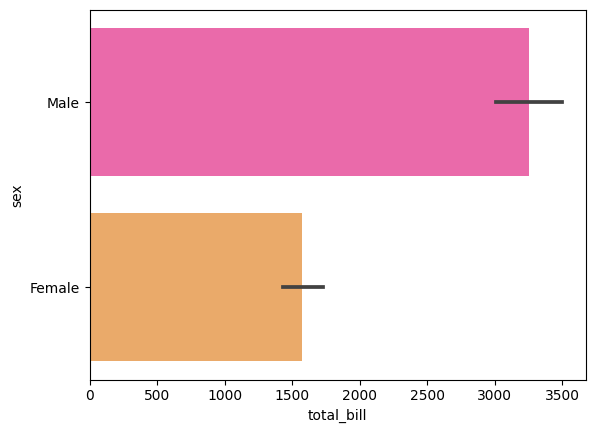

In [267]:
sns.barplot(data = df, x = 'total_bill',y = 'sex',estimator='sum',palette='spring')

E:\test_env\lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


<Axes: xlabel='day', ylabel='total_bill'>

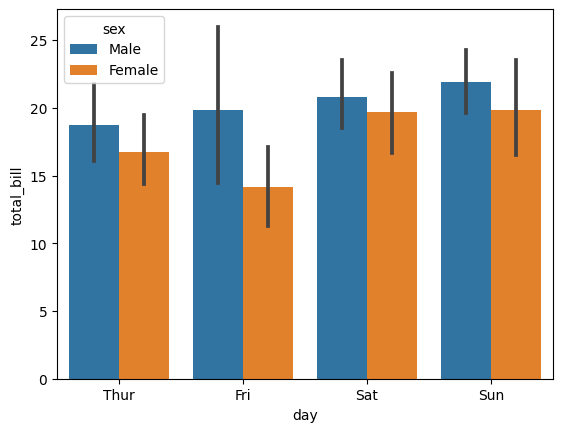

In [268]:
sns.barplot(data = df,x = 'day', y = 'total_bill',hue = 'sex')

In [ ]:
#### MQSQL Installation 
Password and Username -- R